In [26]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [27]:
generator_llm = ChatGroq(model="llama-3.3-70B-versatile")
evaluator_llm = ChatGroq(model="llama-3.3-70B-versatile")
optimizer_llm = ChatGroq(model="llama-3.3-70B-versatile")

In [28]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal['posted', 'needs_revision'] = Field(..., description="Final evaluation result" )
    feedback: str = Field(..., description="Feedback for the tweet if any.") 

In [29]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [30]:
# state 
class TweetState(TypedDict):
    
    topic: str 
    tweet: str 
    evaluation: Literal["posted", "needs_revision"]
    feedback: str 
    iteration: int
    max_iteration: int 
    
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [31]:
def generate_tweet(state: TweetState): 
    
    # prompt 
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on topic: "{state['topic']}".   

Rules: 
- Do Not use question-answer format. 
- Max characters: 200.
- Use observational humor, irony, sarcasm or cultural references.
- Think in meme logic, punchlines, or relatable jokes.
- Use simple, day to day english. 
- This is version {state['iteration'] + 1}.
""")
    ]
    # send generator_llm 
    response = generator_llm.invoke(messages).content
    
    # return response 
    return {'tweet': response, 'tweet_history': [response]}

In [32]:
def evaluate_tweet(state: TweetState):
    
    # prompt
    messages = [
        SystemMessage(content="You are a ruthless no-laugh-given Twitter/X content critic. You evaluate tweets based on humor, originality,  and engagement potential. You provide brutally honest feedback and a clear verdict."),
        HumanMessage(content=f"""
Evaluate the following tweet: "{state['tweet']}" 

Use the criteria below to evaluate the tweet:
                
1. Originality - Is this fresh, or is it a tired joke?  
2. Humor - Does it make you laugh? Is it clever or witty?
3. Punchlines - Id it short, sharp, and scroll-stopping? 
4. Virality Potential - Would people retweet this?
5. Format - Is it well-formed tweet (not a setup punchline joke, or Q&A joke, and under 200 characters)?


Auto-reject if: 
- It's written in question-answer format.
- It exceeds 200 characters.
- It reads like atraditional setup-punchline joke.
- Don't end with generic, throwaway feedback like "Needs work" or "Not good". Be specific and actionable.

### Respond ONLY in structured format:
- evaluation: "posted" or "needs_revision"
- feedback: One paragraph explaining the strengths and drawbacks
""")
]
    
    response = structured_evaluator_llm.invoke(messages)
    
    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [33]:
def optimizer_tweet(state: TweetState):
    
    messages = [
        SystemMessage(content="You push up tweets based on virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on the following feedback:
"{state['feedback']}" 

Topic: "{state['topic']}"
Original Tweet: 
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A format and max 200 characters.                
""")
    ]
    
    response = optimizer_llm.invoke(messages).content 
    iteration = state['iteration'] + 1
    
    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [34]:
def route_evaluation(state: TweetState): 
    
    if state['evaluation'] == 'posted' or state['iteration'] >=  state['max_iteration']:
        return "posted"
    else:
        return "needs_revision"

In [35]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimizer_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'posted': END, 'needs_revision': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

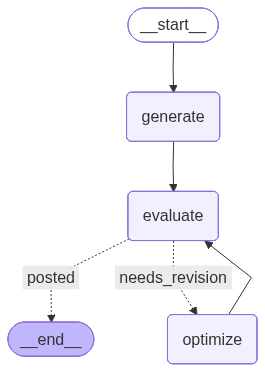

In [36]:
workflow

In [37]:
initial_state = {
    'topic': "BJP govenment of India",
    "iteration": 1,
    "max_iteration": 5
}
workflow.invoke(initial_state)

{'topic': 'BJP govenment of India',
 'tweet': '"Delhi\'s traffic jams are the BJP\'s \'Acche Din\' promise in motion #BJP #India"',
 'evaluation': 'posted',
 'feedback': "This tweet is a great example of a well-crafted, sharp, and witty remark that effectively uses humor to critique the BJP's 'Acche Din' promise. The use of 'in motion' to describe Delhi's traffic jams is clever and original, making it a fresh take on a common joke. The tweet is concise, under 200 characters, and the hashtag #BJP #India adds to its virality potential. The only potential drawback is that the joke may not resonate with everyone, particularly those who are not familiar with the 'Acche Din' promise or Delhi's traffic jams. However, overall, the tweet is well-formed, clever, and has a high chance of being retweeted, making it a strong candidate for posting.",
 'iteration': 2,
 'max_iteration': 5,
 'tweet_history': ['"BJP government: where \'Acche Din\' is just a myth, but traffic jams on Delhi roads are very